# Task 6: Time Series Analysis

### Dataset Selection

In [1]:
!pip install pandas numpy matplotlib statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

#### A sales dataset is loaded.

In [3]:
df = pd.read_csv("sales.csv", parse_dates=["date"], index_col="date")
df = df.sort_index()

### Tasks to Perform

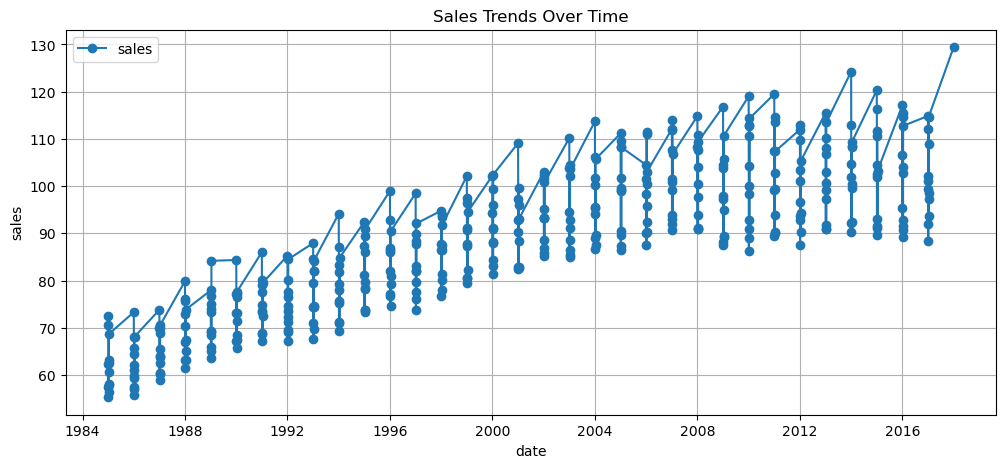

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df, label="sales", marker="o", linestyle="-")
plt.title("Sales Trends Over Time")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()
plt.grid()
plt.show()

#### An ARIMA model (p=2, d=1, q=2) is trained on time series data and used to forecast the next 30 days. The predictions are stored in a time-indexed series for analysis.

In [6]:
import warnings
warnings.filterwarnings("ignore")
p, d, q = 2, 1, 2
model = ARIMA(df, order=(p, d, q))
model_fit = model.fit()

In [7]:
n_periods = 30  
forecast = model_fit.forecast(steps=n_periods)
forecast_index = pd.date_range(start=df.index[-1], periods=n_periods+1, freq='D')[1:]
forecast_series = pd.Series(forecast, index=forecast_index)

#### A line chart visualizes actual and forecasted sales, with actual sales in blue and predicted values in red dashed lines. Labels, a title, a legend, and a grid enhance readability.

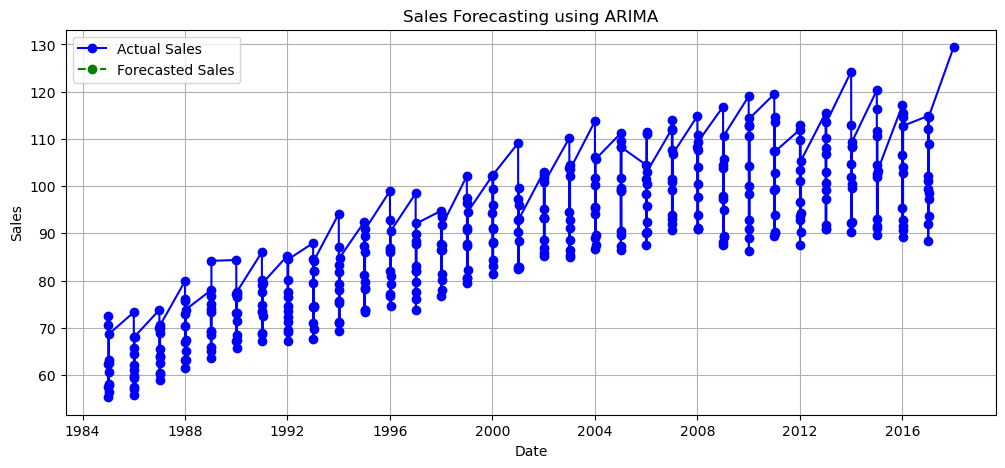

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df, label="Actual Sales", marker="o", color="blue")
plt.plot(forecast_series, label="Forecasted Sales", linestyle="dashed", marker="o", color="green")
plt.title("Sales Forecasting using ARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

#### The dataset is split into 80% training and 20% testing data, with an ARIMA model trained on the training set. The model then forecasts values for the test period to evaluate its performance.

In [11]:
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]
model_fit = ARIMA(train, order=(p, d, q)).fit()
predictions = model_fit.forecast(steps=len(test))

#### The root mean squared error (RMSE) calculates the average prediction error magnitude, while the mean absolute percentage error (MAPE) expresses the error as a percentage of actual values for better interpretability.

In [12]:
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions) * 100

In [13]:
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
forecast_df = pd.DataFrame({"Date": forecast_index, "Forecasted_Sales": forecast})
forecast_df.to_csv("forecasted_sales.csv", index=False)

RMSE: 7.03
MAPE: 5.41%


# Predicting Heart Disease Using Logistic Regression

### Dataset Selection

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [16]:
df=pd.read_csv("heart_disease.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


### Tasks to Perform

#### Missing values are identified.
#### Duplicate rows are removed to maintain data consistency, and any remaining null values are replaced with the column-wise mean to preserve completeness.

In [17]:
print("Missing values:\n", df.isnull().sum())
df = df.drop_duplicates()
df.fillna(df.mean(), inplace=True)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [18]:
features = ["age", "chol", "trestbps"]  
target = "target"  

#### Numerical features are standardized to improve model performance.

In [19]:
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
X = df[features]
y = df[target]

#### The dataset is split into training and testing sets. 
#### A logistic regression model is then trained on the training data and used to predict outcomes for the test set.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [22]:
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Confusion Matrix:
[[14 15]
 [11 21]]
Accuracy: 0.57
Precision: 0.58
Recall: 0.66
F1-score: 0.62


#### A heatmap visualizes the confusion matrix, showing actual versus predicted classifications for heart disease. Labels, a title, and a color scheme enhance clarity in interpreting model performance.

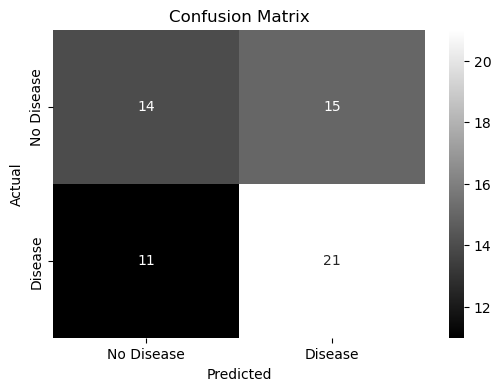

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="gray", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()